In [ ]:
#Step 1 — Import Required Libraries


# Import libraries for data handling
import pandas as pd
import numpy as np

# Library for cleaning text using regular expressions
import re

# Libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Libraries to evaluate model performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#Step 2 — Mount Google Drive

# This connects Google Colab to your Google Drive
# So the notebook can access datasets stored in Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Step 3 — Load the Dataset

# Load the WELFake dataset from Google Drive
# pandas reads the CSV file and converts it into a dataframe

df = pd.read_csv('/content/drive/MyDrive/WELFake_Dataset.csv')

# Display the first 5 rows of the dataset
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
#Step 4 — Remove Unnecessary Column

# The dataset contains an index column called 'Unnamed: 0'
# This column is not useful for machine learning

df = df.drop(columns=['Unnamed: 0'])

In [ ]:
#Step 5 — Remove Missing Values

# Some rows have missing titles or article text
# Machine learning models cannot work with missing text

df = df.dropna()

# Check again if any missing values remain
df.isnull().sum()

,0
title,0
text,0
label,0


In [ ]:
#Step 6 — Combine Title and Text

# Fake news articles contain both a title and body text
# Combining them gives the model more information

df['content'] = df['title'] + " " + df['text']

# Keep only the columns we need for classification
df = df[['content', 'label']]

# Preview dataset
df.head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [ ]:
#Step 7 — Clean the Text

# Define a function to clean text data

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text

# Apply cleaning function to all news articles
df['content'] = df['content'].apply(clean_text)

In [ ]:
#Step 8 — Split Dataset into Training and Testing

# X contains the news text
X = df['content']

# y contains labels (0 = real news, 1 = fake news)
y = df['label']

# Split dataset:
# 80% used to train the model
# 20% used to test model performance

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check sizes of training and testing sets
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (57229,)
Testing data size: (14308,)


In [ ]:
#Step 9 — Convert Text into TF-IDF Features

# Improved TF-IDF vectorizer
# max_features limits vocabulary size
# ngram_range allows single words and word pairs

tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    max_features=10000,
    ngram_range=(1,2)
)

# Learn vocabulary from training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using same vocabulary
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
#Step 10 — Train Logistic Regression Model

# Logistic Regression is a basic but strong classifier for text data

lr = LogisticRegression(max_iter=1000)

# Train the model using training data
lr.fit(X_train_tfidf, y_train)

# Predict labels for the test dataset
lr_pred = lr.predict(X_test_tfidf)

# Evaluate model performance
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9558289069052278
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7081
           1       0.95      0.96      0.96      7227

    accuracy                           0.96     14308
   macro avg       0.96      0.96      0.96     14308
weighted avg       0.96      0.96      0.96     14308



In [ ]:
#Step 11 — Train Support Vector Machine (SVM)

# SVM is very effective for text classification problems

svm = LinearSVC()

# Train the model
svm.fit(X_train_tfidf, y_train)

# Predict results
svm_pred = svm.predict(X_test_tfidf)

# Evaluate performance
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9646351691361477
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      7081
           1       0.96      0.97      0.97      7227

    accuracy                           0.96     14308
   macro avg       0.96      0.96      0.96     14308
weighted avg       0.96      0.96      0.96     14308



In [ ]:
#Step 12 — Train Random Forest Model

# Random Forest uses multiple decision trees
# It is an ensemble learning method

# Faster Random Forest
rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf.fit(X_train_tfidf, y_train)

# Predict labels
rf_pred = rf.predict(X_test_tfidf)

# Evaluate model performance
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.962258876153201
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      7081
           1       0.96      0.97      0.96      7227

    accuracy                           0.96     14308
   macro avg       0.96      0.96      0.96     14308
weighted avg       0.96      0.96      0.96     14308



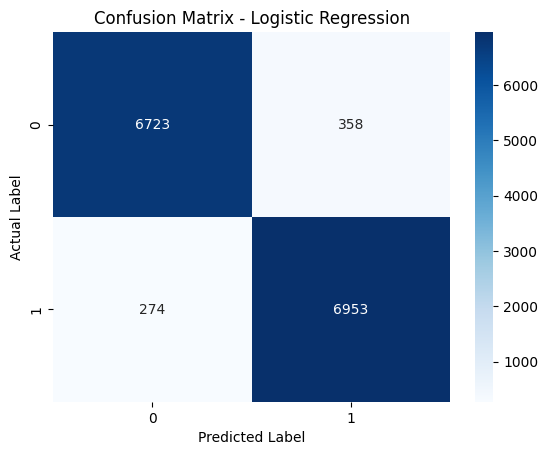

In [ ]:
#Step 13 — Confusion Matrix

# Confusion matrix shows how many predictions were correct or incorrect

cm = confusion_matrix(y_test, lr_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
#Step 14 — Compare Model Performance

# Create a table comparing the accuracy of all models

results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

# Display results
results

,Model,Accuracy
0,Logistic Regression,0.955829
1,SVM,0.964635
2,Random Forest,0.962259


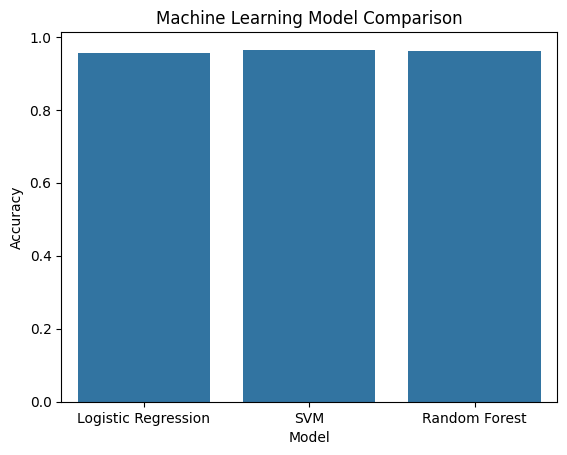

In [ ]:
# Plot model comparison

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

ml_acc = accuracy_score(y_test, lr_pred)
ml_prec = precision_score(y_test, lr_pred)
ml_rec = recall_score(y_test, lr_pred)
ml_f1 = f1_score(y_test, lr_pred)

print("Accuracy:", ml_acc)
print("Precision:", ml_prec)
print("Recall:", ml_rec)
print("F1 Score:", ml_f1)

Accuracy: 0.9558289069052278
Precision: 0.9510326904664205
Recall: 0.9620866196208662
F1 Score: 0.9565277204567341
